# data reading and preprossing

**importhing all the required lybs**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , LabelEncoder , MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, recall_score, precision_score, f1_score
from sklearn.utils import shuffle , resample
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif

**reading and printing data**

In [2]:
data=pd.read_csv("/content/EEG_data.csv")

In [3]:
data

,video_id,subject_id,EEG.AF3,EEG.F7,EEG.F3,EEG.FC5,EEG.T7,EEG.P7,EEG.O1,EEG.O2,...,POW.F8.Alpha,POW.F8.BetaL,POW.F8.BetaH,POW.F8.Gamma,POW.AF4.Theta,POW.AF4.Alpha,POW.AF4.BetaL,POW.AF4.BetaH,POW.AF4.Gamma,subject_understood
0,0,0,4210.641113,4179.102539,4287.948730,4235.384766,4207.948730,4165.000000,4135.897461,4170.000000,...,1.583895,0.504567,0.471979,0.138717,1.801014,1.504794,0.258570,0.435745,0.469483,0
1,0,0,4201.025879,4188.717773,4280.128418,4236.922852,4209.615234,4152.436035,4130.128418,4149.487305,...,1.709560,0.606587,0.527616,0.155580,1.859177,1.379617,0.317579,0.468416,0.642560,0
2,0,0,4203.205078,4182.820313,4282.820313,4231.025879,4207.820313,4172.436035,4131.538574,4147.948730,...,1.873591,0.795834,0.565414,0.170816,2.027946,1.283876,0.441925,0.494701,0.798197,0
3,0,0,4186.538574,4168.717773,4266.794922,4229.230957,4202.179688,4155.384766,4128.333496,4151.666504,...,2.110017,1.021118,0.579656,0.180056,2.265952,1.306188,0.616881,0.506062,0.886495,0
4,0,0,4232.436035,4216.922852,4306.922852,4270.769043,4217.436035,4166.538574,4155.897461,4162.820313,...,2.462552,1.230984,0.573620,0.181081,2.461205,1.522420,0.822598,0.498361,0.874455,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68826,10,7,4353.846191,4349.487305,4317.563965,4343.461426,4375.641113,4296.025879,4351.666504,4309.358887,...,2.088463,0.925704,0.825126,0.576437,2.009375,3.020382,2.115835,1.735570,1.125858,1
68827,10,7,4335.769043,4326.538574,4310.641113,4331.153809,4363.333496,4297.179688,4336.025879,4282.563965,...,1.899325,0.833753,0.786224,0.600227,2.505607,2.680849,1.971062,1.468342,1.250918,1
68828,10,7,4321.666504,4313.205078,4310.000000,4310.384766,4357.436035,4296.025879,4337.563965,4291.153809,...,1.743110,0.789346,0.777936,0.631701,3.082165,2.443027,1.868980,1.213362,1.373250,1
68829,10,7,4334.615234,4316.666504,4318.717773,4339.102539,4370.512695,4297.436035,4333.461426,4297.051270,...,1.603054,0.781398,0.792152,0.661582,3.607407,2.341642,1.780673,0.982586,1.449505,1


**annalizing data using various methods**

In [4]:
print("Dataset Info:")
data.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68831 entries, 0 to 68830
Data columns (total 87 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   video_id            68831 non-null  int64  
 1   subject_id          68831 non-null  int64  
 2   EEG.AF3             68831 non-null  float64
 3   EEG.F7              68831 non-null  float64
 4   EEG.F3              68831 non-null  float64
 5   EEG.FC5             68831 non-null  float64
 6   EEG.T7              68831 non-null  float64
 7   EEG.P7              68831 non-null  float64
 8   EEG.O1              68831 non-null  float64
 9   EEG.O2              68831 non-null  float64
 10  EEG.P8              68831 non-null  float64
 11  EEG.T8              68831 non-null  float64
 12  EEG.FC6             68831 non-null  float64
 13  EEG.F4              68831 non-null  float64
 14  EEG.F8              68831 non-null  float64
 15  EEG.AF4             68831 non-null  flo

In [5]:
print("Column names:")
print(list(data.columns))

Column names:
['video_id', 'subject_id', 'EEG.AF3', 'EEG.F7', 'EEG.F3', 'EEG.FC5', 'EEG.T7', 'EEG.P7', 'EEG.O1', 'EEG.O2', 'EEG.P8', 'EEG.T8', 'EEG.FC6', 'EEG.F4', 'EEG.F8', 'EEG.AF4', 'POW.AF3.Theta', 'POW.AF3.Alpha', 'POW.AF3.BetaL', 'POW.AF3.BetaH', 'POW.AF3.Gamma', 'POW.F7.Theta', 'POW.F7.Alpha', 'POW.F7.BetaL', 'POW.F7.BetaH', 'POW.F7.Gamma', 'POW.F3.Theta', 'POW.F3.Alpha', 'POW.F3.BetaL', 'POW.F3.BetaH', 'POW.F3.Gamma', 'POW.FC5.Theta', 'POW.FC5.Alpha', 'POW.FC5.BetaL', 'POW.FC5.BetaH', 'POW.FC5.Gamma', 'POW.T7.Theta', 'POW.T7.Alpha', 'POW.T7.BetaL', 'POW.T7.BetaH', 'POW.T7.Gamma', 'POW.P7.Theta', 'POW.P7.Alpha', 'POW.P7.BetaL', 'POW.P7.BetaH', 'POW.P7.Gamma', 'POW.O1.Theta', 'POW.O1.Alpha', 'POW.O1.BetaL', 'POW.O1.BetaH', 'POW.O1.Gamma', 'POW.O2.Theta', 'POW.O2.Alpha', 'POW.O2.BetaL', 'POW.O2.BetaH', 'POW.O2.Gamma', 'POW.P8.Theta', 'POW.P8.Alpha', 'POW.P8.BetaL', 'POW.P8.BetaH', 'POW.P8.Gamma', 'POW.T8.Theta', 'POW.T8.Alpha', 'POW.T8.BetaL', 'POW.T8.BetaH', 'POW.T8.Gamma', 'POW.

**cheacking null**

In [6]:
if data.isnull().values.any():
    print("\nMissing values found. Filling with column means...")
    data = data.fillna(data.mean())
else:
    print(data.isna().sum())
    print("\nNo missing values found.")

video_id              0
subject_id            0
EEG.AF3               0
EEG.F7                0
EEG.F3                0
                     ..
POW.AF4.Alpha         0
POW.AF4.BetaL         0
POW.AF4.BetaH         0
POW.AF4.Gamma         0
subject_understood    0
Length: 87, dtype: int64

No missing values found.


In [7]:
numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns[:-1]
categorical_cols = data.select_dtypes(include=['object']).columns

print(f"\nNumerical Columns ({len(numerical_cols)}): {list(numerical_cols)}")
print(f"Categorical Columns ({len(categorical_cols)}): {list(categorical_cols)}")


Numerical Columns (86): ['video_id', 'subject_id', 'EEG.AF3', 'EEG.F7', 'EEG.F3', 'EEG.FC5', 'EEG.T7', 'EEG.P7', 'EEG.O1', 'EEG.O2', 'EEG.P8', 'EEG.T8', 'EEG.FC6', 'EEG.F4', 'EEG.F8', 'EEG.AF4', 'POW.AF3.Theta', 'POW.AF3.Alpha', 'POW.AF3.BetaL', 'POW.AF3.BetaH', 'POW.AF3.Gamma', 'POW.F7.Theta', 'POW.F7.Alpha', 'POW.F7.BetaL', 'POW.F7.BetaH', 'POW.F7.Gamma', 'POW.F3.Theta', 'POW.F3.Alpha', 'POW.F3.BetaL', 'POW.F3.BetaH', 'POW.F3.Gamma', 'POW.FC5.Theta', 'POW.FC5.Alpha', 'POW.FC5.BetaL', 'POW.FC5.BetaH', 'POW.FC5.Gamma', 'POW.T7.Theta', 'POW.T7.Alpha', 'POW.T7.BetaL', 'POW.T7.BetaH', 'POW.T7.Gamma', 'POW.P7.Theta', 'POW.P7.Alpha', 'POW.P7.BetaL', 'POW.P7.BetaH', 'POW.P7.Gamma', 'POW.O1.Theta', 'POW.O1.Alpha', 'POW.O1.BetaL', 'POW.O1.BetaH', 'POW.O1.Gamma', 'POW.O2.Theta', 'POW.O2.Alpha', 'POW.O2.BetaL', 'POW.O2.BetaH', 'POW.O2.Gamma', 'POW.P8.Theta', 'POW.P8.Alpha', 'POW.P8.BetaL', 'POW.P8.BetaH', 'POW.P8.Gamma', 'POW.T8.Theta', 'POW.T8.Alpha', 'POW.T8.BetaL', 'POW.T8.BetaH', 'POW.T8.Ga

In [8]:
print(data)

       video_id  subject_id      EEG.AF3       EEG.F7       EEG.F3  \
0             0           0  4210.641113  4179.102539  4287.948730   
1             0           0  4201.025879  4188.717773  4280.128418   
2             0           0  4203.205078  4182.820313  4282.820313   
3             0           0  4186.538574  4168.717773  4266.794922   
4             0           0  4232.436035  4216.922852  4306.922852   
...         ...         ...          ...          ...          ...   
68826        10           7  4353.846191  4349.487305  4317.563965   
68827        10           7  4335.769043  4326.538574  4310.641113   
68828        10           7  4321.666504  4313.205078  4310.000000   
68829        10           7  4334.615234  4316.666504  4318.717773   
68830        10           7  4328.589844  4308.589844  4310.384766   

           EEG.FC5       EEG.T7       EEG.P7       EEG.O1       EEG.O2  ...  \
0      4235.384766  4207.948730  4165.000000  4135.897461  4170.000000  ...   
1

In [9]:
target=data['subject_understood']

# X and Y

In [10]:
y=data['subject_understood']
x=data.drop('subject_understood',axis=1)

### Y

**basic info of target variable**

In [11]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 68831 entries, 0 to 68830
Series name: subject_understood
Non-Null Count  Dtype
--------------  -----
68831 non-null  int64
dtypes: int64(1)
memory usage: 537.9 KB


**mathamathical and density description**

In [12]:
y.describe()

,subject_understood
count,68831.000000
mean,0.789906
std,0.407378
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000


In [13]:
y.value_counts()

,count
subject_understood,
1,54370
0,14461


In [14]:
target.value_counts()

,count
subject_understood,
1,54370
0,14461


/tmp/ipython-input-15-914007978.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=y, palette='viridis')


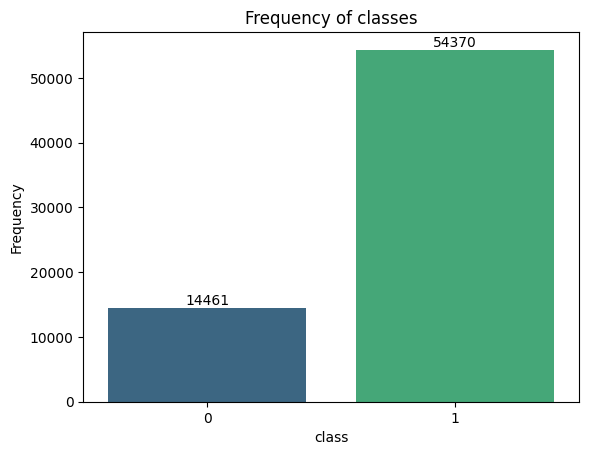

In [15]:
# count of target variable
import matplotlib.pyplot as plt
ax = sns.countplot(x=y, palette='viridis')
plt.title('Frequency of classes')
plt.xlabel('class')
plt.ylabel('Frequency')
for container in ax.containers:
    ax.bar_label(container)

plt.show()

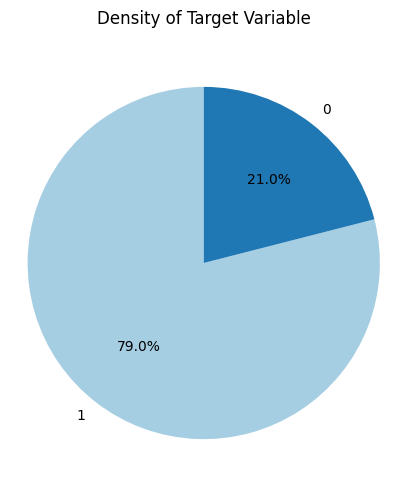

In [16]:
target_counts = target.value_counts()
target_labels = target_counts.index
target_values = target_counts.values

plt.figure(figsize=(5,6))
plt.pie(
    target_values,
    labels=target_labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Paired.colors
)
plt.title('Density of Target Variable')
plt.axis('equal')
plt.show()

### X

In [17]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68831 entries, 0 to 68830
Data columns (total 86 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   video_id       68831 non-null  int64  
 1   subject_id     68831 non-null  int64  
 2   EEG.AF3        68831 non-null  float64
 3   EEG.F7         68831 non-null  float64
 4   EEG.F3         68831 non-null  float64
 5   EEG.FC5        68831 non-null  float64
 6   EEG.T7         68831 non-null  float64
 7   EEG.P7         68831 non-null  float64
 8   EEG.O1         68831 non-null  float64
 9   EEG.O2         68831 non-null  float64
 10  EEG.P8         68831 non-null  float64
 11  EEG.T8         68831 non-null  float64
 12  EEG.FC6        68831 non-null  float64
 13  EEG.F4         68831 non-null  float64
 14  EEG.F8         68831 non-null  float64
 15  EEG.AF4        68831 non-null  float64
 16  POW.AF3.Theta  68831 non-null  float64
 17  POW.AF3.Alpha  68831 non-null  float64
 18  POW.AF

In [18]:
x.describe()

,video_id,subject_id,EEG.AF3,EEG.F7,EEG.F3,EEG.FC5,EEG.T7,EEG.P7,EEG.O1,EEG.O2,...,POW.F8.Theta,POW.F8.Alpha,POW.F8.BetaL,POW.F8.BetaH,POW.F8.Gamma,POW.AF4.Theta,POW.AF4.Alpha,POW.AF4.BetaL,POW.AF4.BetaH,POW.AF4.Gamma
count,68831.000000,68831.000000,68831.000000,68831.000000,68831.000000,68831.000000,68831.000000,68831.000000,68831.000000,68831.000000,...,68831.000000,68831.000000,68831.000000,68831.000000,68831.000000,68831.000000,68831.000000,68831.000000,68831.000000,68831.000000
mean,5.624297,3.710828,4276.496212,4257.994590,4302.803482,4292.027479,4302.093465,4243.397476,4231.846947,4240.153361,...,18.805146,5.386578,2.847343,1.356892,0.770303,22.591861,8.133554,3.861532,1.520038,0.697575
std,2.215993,1.828410,115.584631,140.884855,113.720961,135.578849,117.727171,118.189886,115.590762,137.366806,...,146.070125,42.886793,36.480798,17.930204,8.991064,150.716768,51.722390,35.243356,13.153730,3.937423
min,0.000000,0.000000,1030.769287,805.384644,1320.769287,806.538452,1904.487183,1710.769287,1794.871826,1466.538452,...,0.183836,0.051299,0.036999,0.062924,0.043833,0.195020,0.077566,0.041230,0.056951,0.035907
25%,5.000000,3.000000,4258.461426,4236.410156,4283.205078,4273.077148,4282.436035,4220.769043,4211.602539,4218.205078,...,2.124010,1.093447,0.619023,0.340121,0.166746,1.840644,0.997642,0.511406,0.284404,0.139540
50%,6.000000,4.000000,4287.307617,4266.538574,4305.897461,4297.436035,4312.179688,4253.846191,4244.487305,4252.948730,...,3.987646,1.921246,1.032671,0.612935,0.366483,3.317688,1.679386,0.833078,0.472978,0.262676
75%,6.000000,4.000000,4311.153809,4296.153809,4327.692383,4322.563965,4342.179688,4282.820313,4271.794922,4279.615234,...,10.187227,3.587066,1.850553,1.076909,0.708885,7.129672,3.035433,1.464920,0.837565,0.516598
max,10.000000,7.000000,6238.077148,7599.615234,6291.794922,7600.128418,7599.615234,6695.641113,7525.128418,7611.025879,...,12533.070310,3825.365967,3803.180664,2010.126343,966.228027,8159.436035,3092.790283,3372.114746,1347.074341,331.578979


In [19]:
l=[]
for i in x.columns:
  if (len(x[i].unique())==1):
    l.append(i)
    print(f"{i} column has only one unique value over all i,e. {x[i].unique()}")
    print("\nValue Counts:\n", x[i].value_counts())

    plt.figure(figsize=(6, 4))
    sns.countplot(x=x[i])
    plt.title(f'Frequency of {i}')
    plt.xlabel('Value')
    plt.ylabel('Frequency')

    plt.show()

    print(f"so we can drop {i} from x")
    x = x.drop(i,axis=1)

    print("\n" + "=" * 127 + "\n")

In [20]:
if all(item not in x.columns for item in l):
  print("sucessfully dropped")
else:
  print("failed to drop")

sucessfully dropped


### split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Training Features shape (X_train):",X_train.shape)
print("\nTraining Labels shape (y_train):",y_train.shape)
print("\nTesting Features shape (X_test):",X_test.shape)
print("\nTesting Labels shape (y_test):",y_test.shape)

Training Features shape (X_train): (55064, 86)

Training Labels shape (y_train): (55064,)

Testing Features shape (X_test): (13767, 86)

Testing Labels shape (y_test): (13767,)


# Training


In [22]:
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [23]:
per = Perceptron()
LR = LogisticRegression()
svm=SVC()
knn=KNeighborsClassifier(n_neighbors=8)
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()
record={}

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc

from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

def print_metrics(model,y_true, y_pred, y_proba):
    print(f"Metrics for {model} :")
    print("---------------------------------")
    print(f"Accuracy       : {accuracy_score(y_true.astype(int), y_pred.astype(int)):.4f}")
    print(f"Precision      : {precision_score(y_true.astype(int), y_pred.astype(int)):.4f}")
    print(f"Recall         : {recall_score(y_true.astype(int), y_pred.astype(int)):.4f}")
    print(f"F1 Score       : {f1_score(y_true.astype(int), y_pred.astype(int)):.4f}")

def plot_confusion_matrix_heatmap(model, y_true, y_pred, labels=None):
    y_true = y_true.astype(int)
    y_pred = y_pred.astype(int)
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))

    if labels is None:
        labels = np.unique(y_true)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix Heatmap of {model}')
    plt.show()

def plot_roc_curve(y_true, y_proba):

    y_true_binary = y_true.astype(int)

    fpr, tpr, thresholds = roc_curve(y_true_binary, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_accuracy_comparison(record):
    models = list(record.keys())
    accuracies = list(record.values())

    plt.figure(figsize=(10, 6))
    bars = plt.bar(models, accuracies, color='skyblue', edgecolor='black')

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2f}', ha='center', va='bottom')

    plt.title('Model Accuracy Comparison')
    plt.xlabel('Models')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1.1)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [25]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (55064, 86)
X_test shape: (13767, 86)
y_train shape: (55064,)
y_test shape: (13767,)


###**Perceptron**

In [26]:
y_train = y_train.astype(int)
per = Perceptron()
per.fit(X_train, y_train)
y_pred = per.predict(X_test)
y_proba = per.decision_function(X_test)
model='perceptron'
record[model]=accuracy_score(y_test.astype(int), y_pred)

In [27]:
print_metrics(model, y_test, y_pred, y_proba)

Metrics for perceptron :
---------------------------------
Accuracy       : 0.8512
Precision      : 0.8525
Recall         : 0.9816
F1 Score       : 0.9125


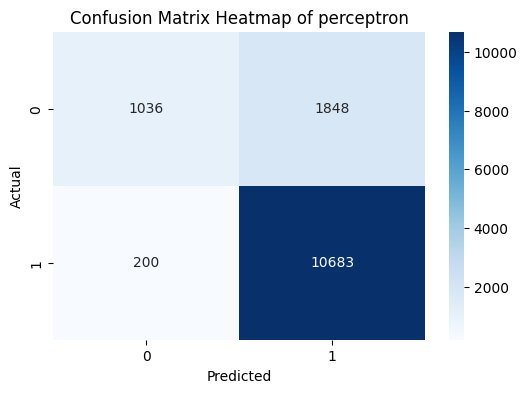

In [28]:
plot_confusion_matrix_heatmap(model,y_test, y_pred, labels=None)

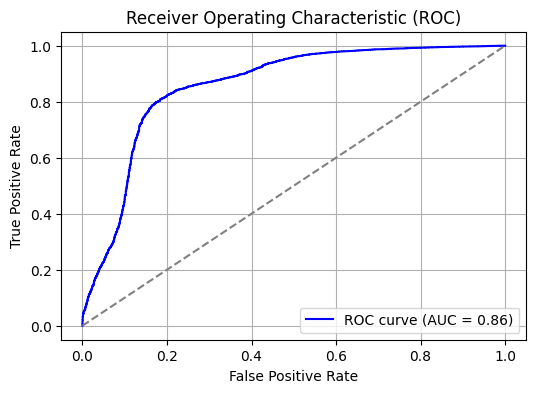

In [29]:
plot_roc_curve(y_test, y_proba)

In [30]:
print(classification_report(y_test.astype(int), y_pred))

              precision    recall  f1-score   support

           0       0.84      0.36      0.50      2884
           1       0.85      0.98      0.91     10883

    accuracy                           0.85     13767
   macro avg       0.85      0.67      0.71     13767
weighted avg       0.85      0.85      0.83     13767



###**Logistic Regression**

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Metrics for logistic_regression :
---------------------------------
Accuracy       : 0.8631
Precision      : 0.8708
Recall         : 0.9708
F1 Score       : 0.9181


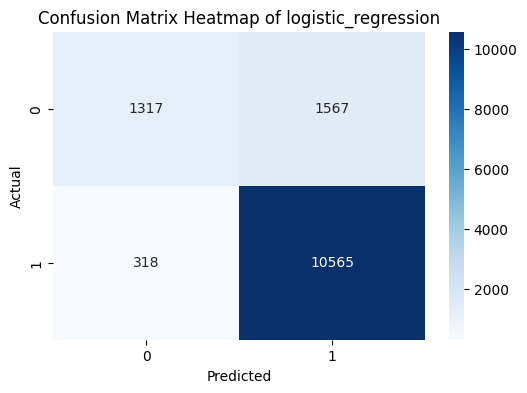

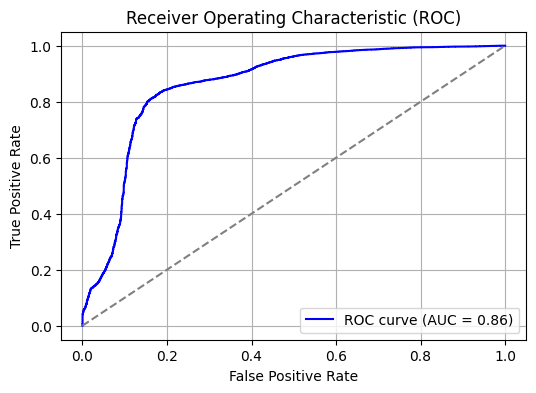

              precision    recall  f1-score   support

           0       0.81      0.46      0.58      2884
           1       0.87      0.97      0.92     10883

    accuracy                           0.86     13767
   macro avg       0.84      0.71      0.75     13767
weighted avg       0.86      0.86      0.85     13767



In [31]:
LR = LogisticRegression()
LR.fit(X_train, y_train)
y_pred = LR.predict(X_test)
y_proba = LR.predict_proba(X_test)[:, 1]
model = 'logistic_regression'
record[model] = accuracy_score(y_test.astype(int), y_pred.astype(int))
print_metrics(model, y_test, y_pred, y_proba)
plot_confusion_matrix_heatmap(model, y_test.astype(int), y_pred.astype(int))
plot_roc_curve(y_test.astype(int), y_proba)
print(classification_report(y_test.astype(int), y_pred.astype(int)))

###**SVM**

In [32]:
# from sklearn.svm import SVC
# from sklearn.metrics import accuracy_score, classification_report

# svm = SVC(probability=True)
# svm.fit(X_train, y_train)
# y_pred = svm.predict(X_test)
# y_proba = svm.predict_proba(X_test)[:, 1]
# model = 'svm'
# # Convert y_test and y_pred to integer type before calculating accuracy
# record[model] = accuracy_score(y_test.astype(int), y_pred.astype(int))

# y_pred_int = y_pred.astype(int)
# y_test_int = y_test.astype(int)

# print_metrics(model, y_test_int, y_pred_int, y_proba)
# plot_confusion_matrix_heatmap(model, y_test_int, y_pred_int)
# plot_roc_curve(y_test_int, y_proba)
# print(classification_report(y_test_int, y_pred_int))

### KNN

Metrics for knn :
---------------------------------
Accuracy       : 0.9523
Precision      : 0.9712
Recall         : 0.9684
F1 Score       : 0.9698


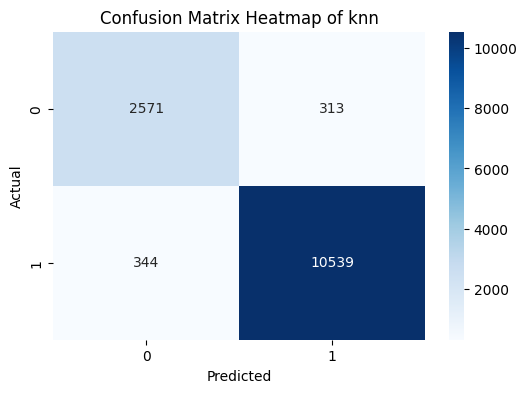

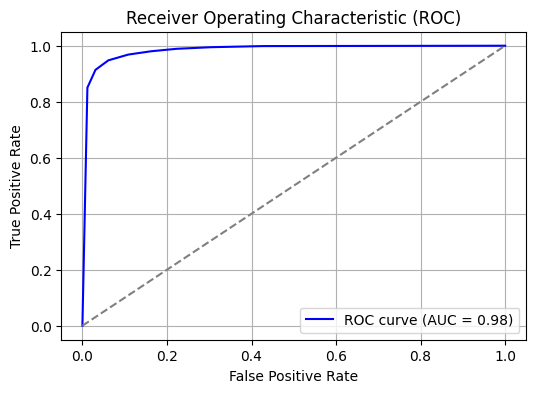

              precision    recall  f1-score   support

           0       0.88      0.89      0.89      2884
           1       0.97      0.97      0.97     10883

    accuracy                           0.95     13767
   macro avg       0.93      0.93      0.93     13767
weighted avg       0.95      0.95      0.95     13767



In [33]:
from sklearn.neighbors import KNeighborsClassifier
# KNN
knn = KNeighborsClassifier(n_neighbors=8)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
y_proba = knn.predict_proba(X_test)[:, 1]
model = 'knn'
record[model] = accuracy_score(y_test.astype(int), y_pred.astype(int))
print_metrics(model, y_test.astype(int), y_pred.astype(int), y_proba)
plot_confusion_matrix_heatmap(model, y_test.astype(int), y_pred.astype(int))
plot_roc_curve(y_test.astype(int), y_proba)
print(classification_report(y_test.astype(int), y_pred.astype(int)))

### DT

Metrics for decision_tree :
---------------------------------
Accuracy       : 0.9999
Precision      : 0.9999
Recall         : 1.0000
F1 Score       : 1.0000


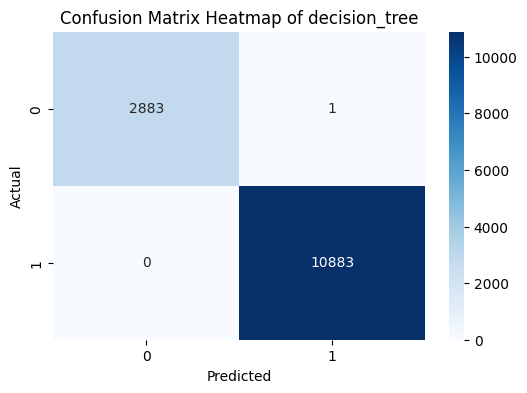

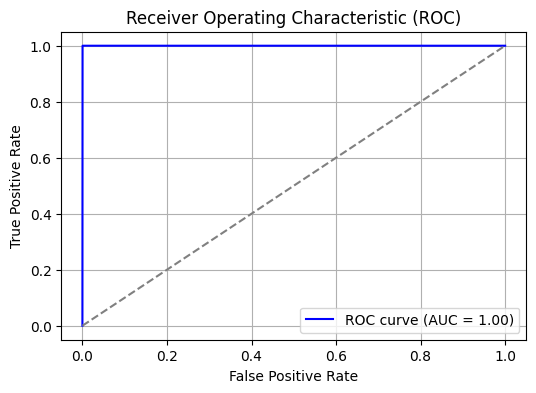

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2884
           1       1.00      1.00      1.00     10883

    accuracy                           1.00     13767
   macro avg       1.00      1.00      1.00     13767
weighted avg       1.00      1.00      1.00     13767



In [34]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
y_proba = dt.predict_proba(X_test)[:, 1]
model = 'decision_tree'
record[model] = accuracy_score(y_test.astype(int), y_pred.astype(int))
print_metrics(model, y_test.astype(int), y_pred.astype(int), y_proba)
plot_confusion_matrix_heatmap(model, y_test.astype(int), y_pred.astype(int))
plot_roc_curve(y_test.astype(int), y_proba)
print(classification_report(y_test.astype(int), y_pred.astype(int)))

### RF

Metrics for random_forest :
---------------------------------
Accuracy       : 0.9999
Precision      : 1.0000
Recall         : 0.9999
F1 Score       : 1.0000


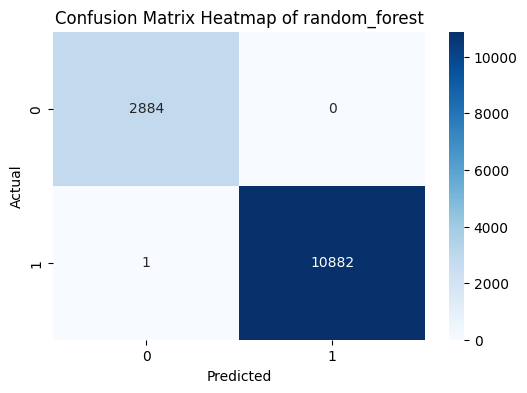

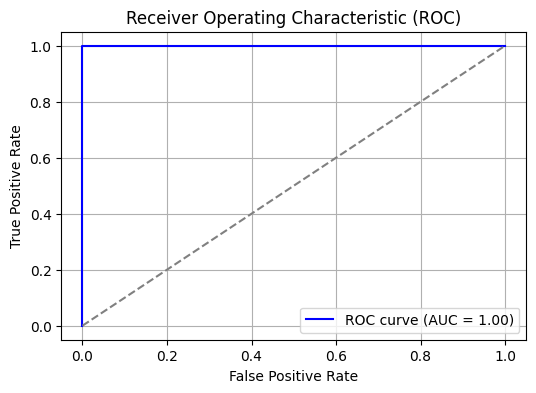

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2884
           1       1.00      1.00      1.00     10883

    accuracy                           1.00     13767
   macro avg       1.00      1.00      1.00     13767
weighted avg       1.00      1.00      1.00     13767



In [35]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]
model = 'random_forest'
record[model] = accuracy_score(y_test.astype(int), y_pred.astype(int))
print_metrics(model, y_test.astype(int), y_pred.astype(int), y_proba)
plot_confusion_matrix_heatmap(model, y_test.astype(int), y_pred.astype(int))
plot_roc_curve(y_test.astype(int), y_proba)
print(classification_report(y_test.astype(int), y_pred.astype(int)))


# Random forest is best before smote among other models it is analyzed by their classification reports

### comparision

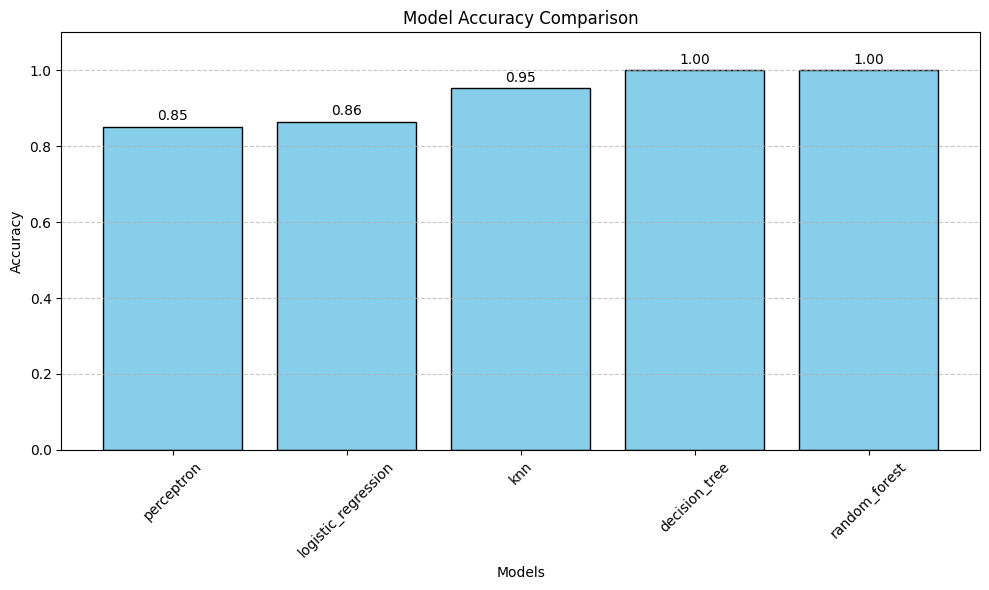

In [36]:
plot_accuracy_comparison(record)

# SMOTE

In [37]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
y_train = y_train.astype(int)
y_test = y_test.astype(int)

X_train1, y_train1 = X_train, y_train
X_train, y_train = smote.fit_resample(X_train, y_train)

x_test1, y_test1 = X_test, y_test
X_test, y_test = smote.fit_resample(X_test, y_test)


In [38]:
from collections import Counter

print("Before SMOTE:", Counter(y_train1))
print("After SMOTE :", Counter(y_train))
print(Counter(y_test1))
print(Counter(y_test))


Before SMOTE: Counter({1: 43487, 0: 11577})
After SMOTE : Counter({1: 43487, 0: 43487})
Counter({1: 10883, 0: 2884})
Counter({1: 10883, 0: 10883})


# Training after SMOTE


In [39]:
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

In [40]:
per = Perceptron()
LR = LogisticRegression()
svm=SVC()
knn=KNeighborsClassifier(n_neighbors=8)
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()
record_smote={}

In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc


def print_metrics(model,y_true, y_pred, y_proba):
    print(f"Metrics for {model} :")
    print("---------------------------------")
    print(f"Accuracy       : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision      : {precision_score(y_true, y_pred):.4f}")
    print(f"Recall         : {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score       : {f1_score(y_true, y_pred):.4f}")

def plot_confusion_matrix_heatmap(model, y_true, y_pred, labels=None):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))

    if labels is None:
        labels = np.unique(y_true)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix Heatmap of {model}')
    plt.show()

def plot_roc_curve(y_true, y_proba):
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_accuracy_comparison(record):
    models = list(record.keys())
    accuracies = list(record.values())

    plt.figure(figsize=(10, 6))
    bars = plt.bar(models, accuracies, color='skyblue', edgecolor='black')

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2f}', ha='center', va='bottom')

    plt.title('Model Accuracy Comparison')
    plt.xlabel('Models')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1.1)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

###**Perceptron**

In [42]:
per = Perceptron()
per.fit(X_train, y_train)
y_pred = per.predict(X_test)
y_proba = per.decision_function(X_test)
model='perceptron'
record_smote[model]=accuracy_score(y_test, y_pred)

In [43]:
print_metrics(model, y_test, y_pred, y_proba)

Metrics for perceptron :
---------------------------------
Accuracy       : 0.8044
Precision      : 0.8275
Recall         : 0.7690
F1 Score       : 0.7972


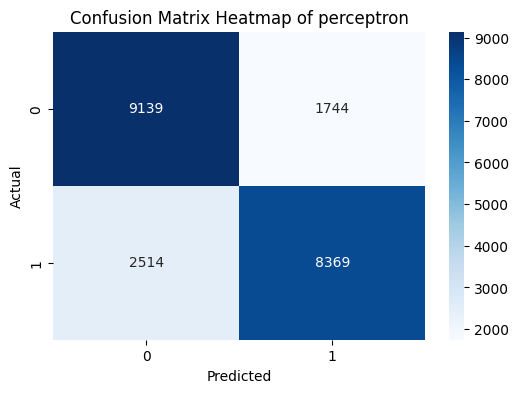

In [44]:
plot_confusion_matrix_heatmap(model,y_test, y_pred, labels=None)

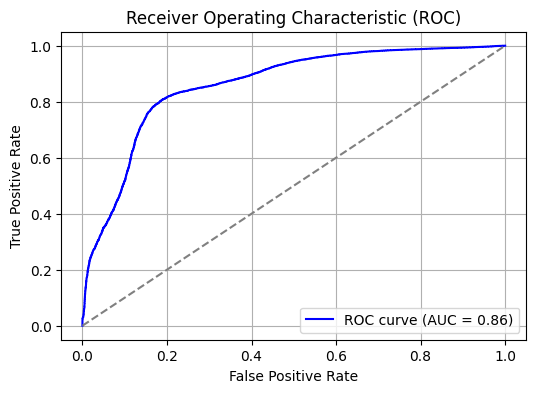

In [45]:
plot_roc_curve(y_test, y_proba)

In [46]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.84      0.81     10883
           1       0.83      0.77      0.80     10883

    accuracy                           0.80     21766
   macro avg       0.81      0.80      0.80     21766
weighted avg       0.81      0.80      0.80     21766



###**Logistic Regression**

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Metrics for logistic_regression :
---------------------------------
Accuracy       : 0.8048
Precision      : 0.7841
Recall         : 0.8412
F1 Score       : 0.8116


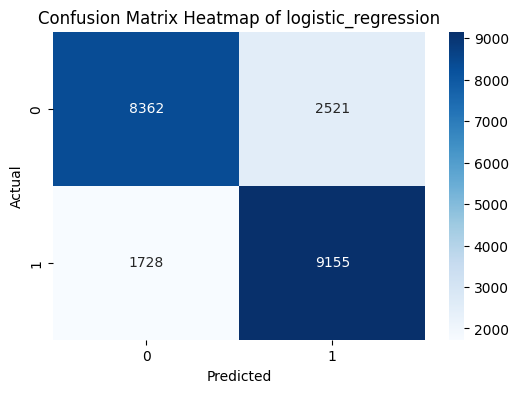

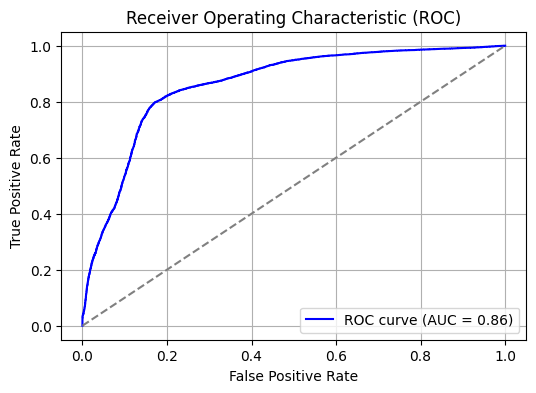

              precision    recall  f1-score   support

           0       0.83      0.77      0.80     10883
           1       0.78      0.84      0.81     10883

    accuracy                           0.80     21766
   macro avg       0.81      0.80      0.80     21766
weighted avg       0.81      0.80      0.80     21766



In [47]:
LR = LogisticRegression()
LR.fit(X_train, y_train)
y_pred = LR.predict(X_test)
y_proba = LR.predict_proba(X_test)[:, 1]
model = 'logistic_regression'
record_smote[model] = accuracy_score(y_test, y_pred)

print_metrics(model, y_test, y_pred, y_proba)
plot_confusion_matrix_heatmap(model, y_test, y_pred)
plot_roc_curve(y_test, y_proba)
print(classification_report(y_test, y_pred))

###**SVM**

In [48]:
# #svm
# from sklearn.svm import SVC
# from sklearn.metrics import accuracy_score, classification_report

# svm = SVC(probability=True)
# svm.fit(X_train, y_train)

# y_pred = svm.predict(X_test).astype(int)
# y_proba = svm.predict_proba(X_test)[:, 1]
# y_test_int = y_test.astype(int)

# model = 'svm'
# record[model] = accuracy_score(y_test, y_pred)

# print_metrics(model, y_test_int, y_pred, y_proba)
# plot_confusion_matrix_heatmap(model, y_test_int, y_pred)
# plot_roc_curve(y_test_int, y_proba)
# print(classification_report(y_test_int, y_pred))


### KNN

Metrics for knn :
---------------------------------
Accuracy       : 0.9449
Precision      : 0.9749
Recall         : 0.9134
F1 Score       : 0.9431


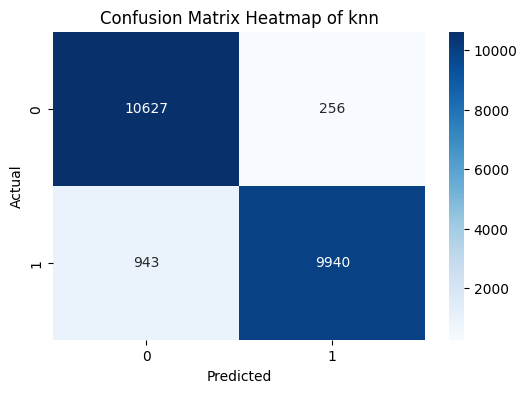

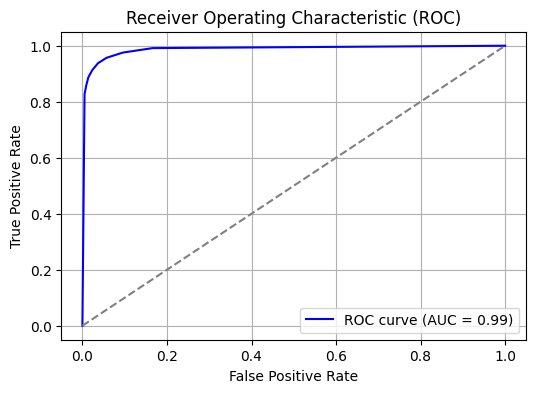

              precision    recall  f1-score   support

           0       0.92      0.98      0.95     10883
           1       0.97      0.91      0.94     10883

    accuracy                           0.94     21766
   macro avg       0.95      0.94      0.94     21766
weighted avg       0.95      0.94      0.94     21766



In [49]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=8)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
y_proba = knn.predict_proba(X_test)[:, 1]
model = 'knn'
record_smote[model] = accuracy_score(y_test, y_pred)

print_metrics(model, y_test, y_pred, y_proba)
plot_confusion_matrix_heatmap(model, y_test, y_pred)
plot_roc_curve(y_test, y_proba)
print(classification_report(y_test, y_pred))

### DT

Metrics for decision_tree :
---------------------------------
Accuracy       : 0.9951
Precision      : 0.9924
Recall         : 0.9979
F1 Score       : 0.9951


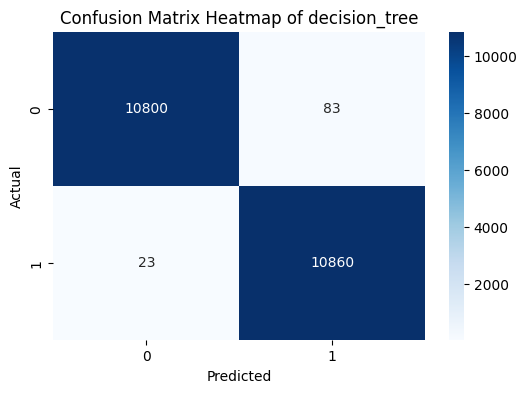

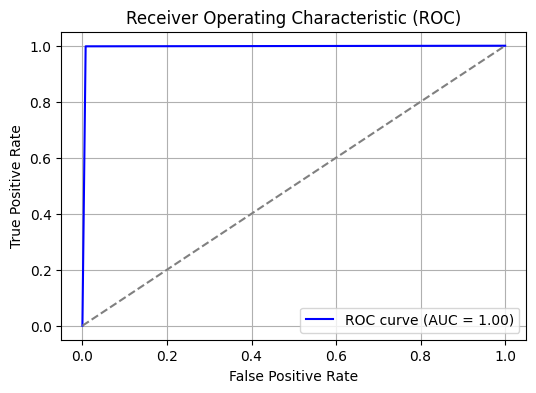

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     10883
           1       0.99      1.00      1.00     10883

    accuracy                           1.00     21766
   macro avg       1.00      1.00      1.00     21766
weighted avg       1.00      1.00      1.00     21766



In [50]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
y_proba = dt.predict_proba(X_test)[:, 1]
model = 'decision_tree'
record_smote[model] = accuracy_score(y_test, y_pred)

print_metrics(model, y_test, y_pred, y_proba)
plot_confusion_matrix_heatmap(model, y_test, y_pred)
plot_roc_curve(y_test, y_proba)
print(classification_report(y_test, y_pred))

### RF

Metrics for random_forest :
---------------------------------
Accuracy       : 0.9986
Precision      : 0.9973
Recall         : 0.9998
F1 Score       : 0.9986


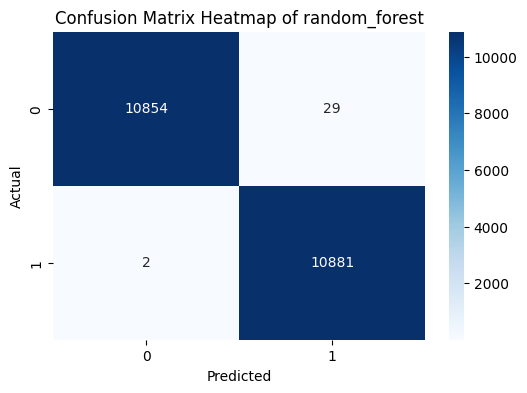

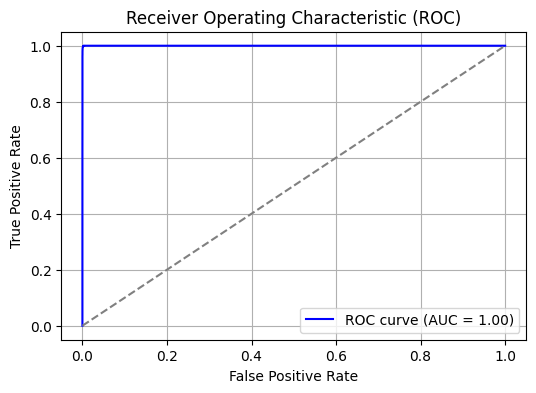

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10883
           1       1.00      1.00      1.00     10883

    accuracy                           1.00     21766
   macro avg       1.00      1.00      1.00     21766
weighted avg       1.00      1.00      1.00     21766



In [51]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]
model = 'random_forest'
record_smote[model] = accuracy_score(y_test, y_pred)

print_metrics(model, y_test, y_pred, y_proba)
plot_confusion_matrix_heatmap(model, y_test, y_pred)
plot_roc_curve(y_test, y_proba)
print(classification_report(y_test, y_pred))

# Both decision treee and random forest are the best models after smote analyzed by comparing their classification reports

### comparision after smote

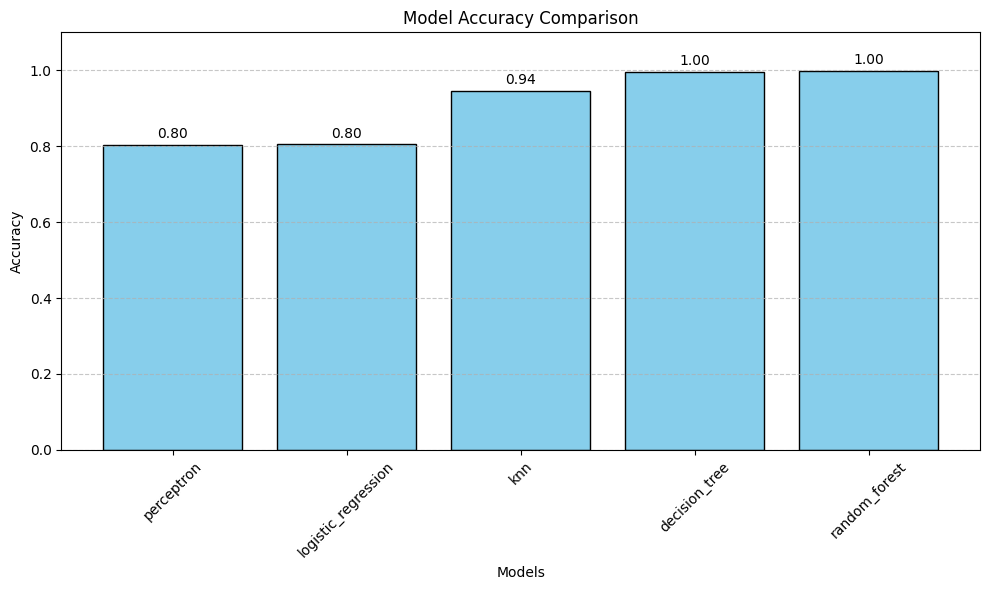

In [52]:
plot_accuracy_comparison(record_smote)

# PCA

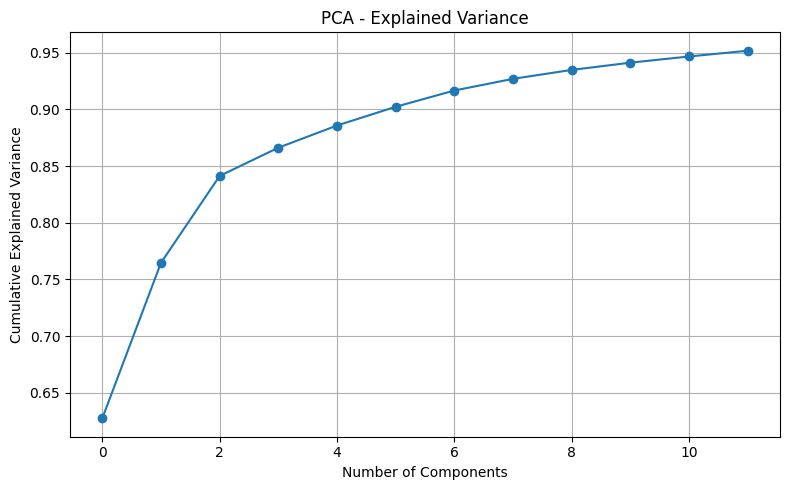

Number of components selected: 12


In [53]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=0.95)
X_train = pca.fit_transform(X_train_scaled)
X_test = pca.transform(X_test_scaled)

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Explained Variance')
plt.grid(True)
plt.tight_layout()
plt.show()

print("Number of components selected:", pca.n_components_)

# Training


In [54]:
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [55]:
per = Perceptron()
LR = LogisticRegression()
svm=SVC()
knn=KNeighborsClassifier(n_neighbors=8)
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()
record_PCA={}

In [56]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc


def print_metrics(model,y_true, y_pred, y_proba):
    print(f"Metrics for {model} :")
    print("---------------------------------")
    print(f"Accuracy       : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision      : {precision_score(y_true, y_pred):.4f}")
    print(f"Recall         : {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score       : {f1_score(y_true, y_pred):.4f}")

def plot_confusion_matrix_heatmap(model, y_true, y_pred, labels=None):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))

    if labels is None:
        labels = np.unique(y_true)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix Heatmap of {model}')
    plt.show()

def plot_roc_curve(y_true, y_proba):
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_accuracy_comparison(record):
    models = list(record.keys())
    accuracies = list(record.values())

    plt.figure(figsize=(10, 6))
    bars = plt.bar(models, accuracies, color='skyblue', edgecolor='black')

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2f}', ha='center', va='bottom')

    plt.title('Model Accuracy Comparison')
    plt.xlabel('Models')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1.1)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


###**Perceptron**

In [57]:
per = Perceptron()
per.fit(X_train, y_train)
y_pred = per.predict(X_test)
y_proba = per.decision_function(X_test)
model='perceptron'
record_PCA[model]=accuracy_score(y_test, y_pred)

In [58]:
print_metrics(model, y_test, y_pred, y_proba)

Metrics for perceptron :
---------------------------------
Accuracy       : 0.6582
Precision      : 0.6742
Recall         : 0.6123
F1 Score       : 0.6418


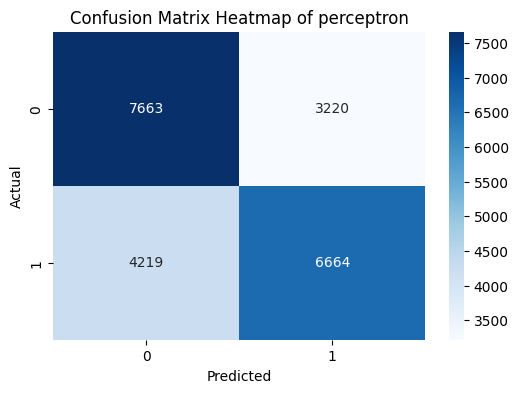

In [59]:
plot_confusion_matrix_heatmap(model,y_test, y_pred, labels=None)

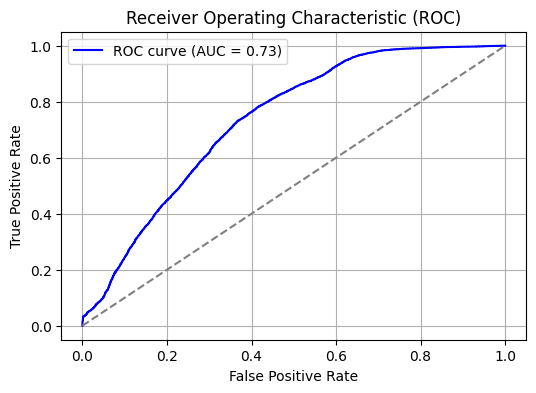

In [60]:
plot_roc_curve(y_test, y_proba)

In [61]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.64      0.70      0.67     10883
           1       0.67      0.61      0.64     10883

    accuracy                           0.66     21766
   macro avg       0.66      0.66      0.66     21766
weighted avg       0.66      0.66      0.66     21766



###**Logistic Regression**

Metrics for logistic_regression :
---------------------------------
Accuracy       : 0.8667
Precision      : 0.8651
Recall         : 0.8689
F1 Score       : 0.8670


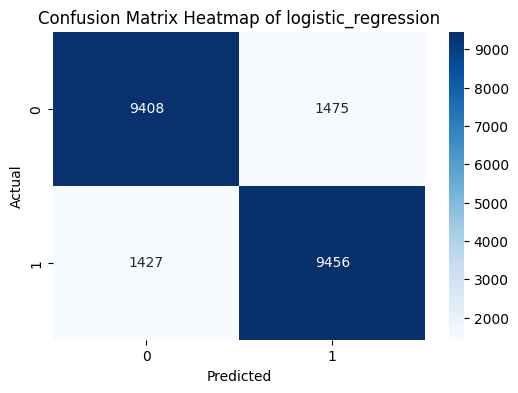

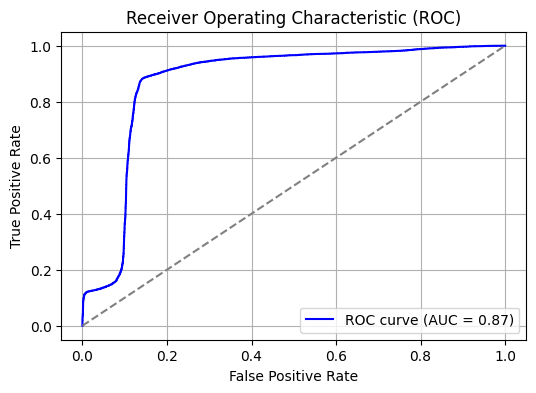

              precision    recall  f1-score   support

           0       0.87      0.86      0.87     10883
           1       0.87      0.87      0.87     10883

    accuracy                           0.87     21766
   macro avg       0.87      0.87      0.87     21766
weighted avg       0.87      0.87      0.87     21766



In [62]:
LR = LogisticRegression()
LR.fit(X_train, y_train)
y_pred = LR.predict(X_test)
y_proba = LR.predict_proba(X_test)[:, 1]
model = 'logistic_regression'
record_PCA[model] = accuracy_score(y_test, y_pred)

print_metrics(model, y_test, y_pred, y_proba)
plot_confusion_matrix_heatmap(model, y_test, y_pred)
plot_roc_curve(y_test, y_proba)
print(classification_report(y_test, y_pred))

###**SVM**

In [63]:
# svm = SVC(probability=True)
# svm.fit(X_train, y_train)

# y_pred = svm.predict(X_test).astype(int)
# y_proba = svm.predict_proba(X_test)[:, 1]
# y_test_int = y_test.astype(int)

# model = 'svm'
# record_PCA[model] = accuracy_score(y_test_int, y_pred)

# print_metrics(model, y_test_int, y_pred, y_proba)
# plot_confusion_matrix_heatmap(model, y_test_int, y_pred)
# plot_roc_curve(y_test_int, y_proba)
# print(classification_report(y_test_int, y_pred))


### KNN

Metrics for knn :
---------------------------------
Accuracy       : 0.9951
Precision      : 0.9949
Recall         : 0.9952
F1 Score       : 0.9951


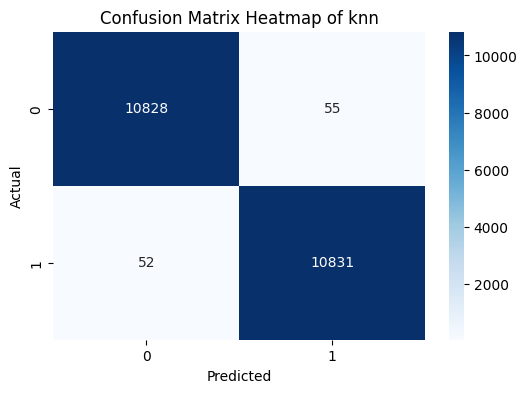

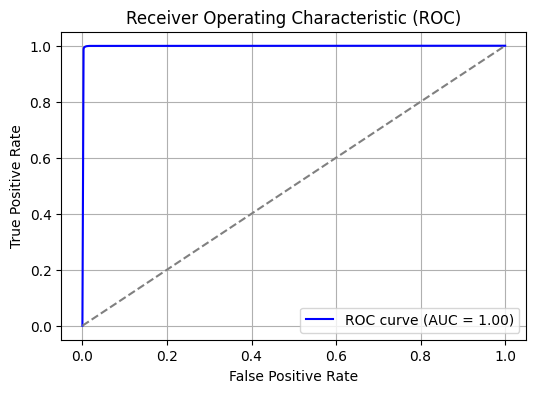

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     10883
           1       0.99      1.00      1.00     10883

    accuracy                           1.00     21766
   macro avg       1.00      1.00      1.00     21766
weighted avg       1.00      1.00      1.00     21766



In [64]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=8)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
y_proba = knn.predict_proba(X_test)[:, 1]
model = 'knn'
record_PCA[model] = accuracy_score(y_test, y_pred)

print_metrics(model, y_test, y_pred, y_proba)
plot_confusion_matrix_heatmap(model, y_test, y_pred)
plot_roc_curve(y_test, y_proba)
print(classification_report(y_test, y_pred))

### DT

Metrics for decision_tree :
---------------------------------
Accuracy       : 0.9928
Precision      : 0.9910
Recall         : 0.9947
F1 Score       : 0.9928


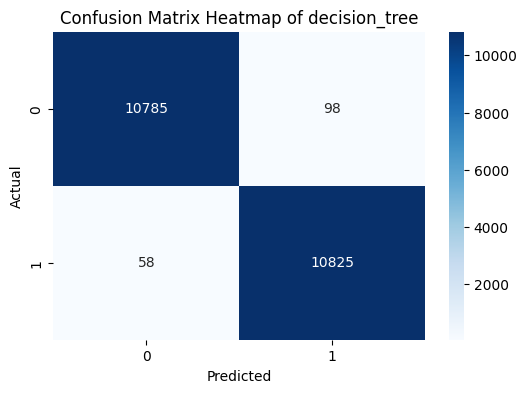

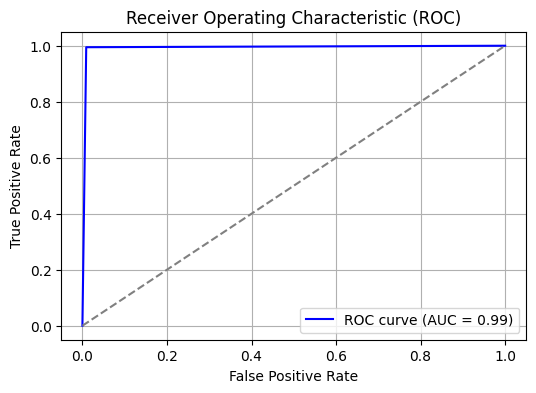

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     10883
           1       0.99      0.99      0.99     10883

    accuracy                           0.99     21766
   macro avg       0.99      0.99      0.99     21766
weighted avg       0.99      0.99      0.99     21766



In [65]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
y_proba = dt.predict_proba(X_test)[:, 1]
model = 'decision_tree'
record_PCA[model] = accuracy_score(y_test, y_pred)

print_metrics(model, y_test, y_pred, y_proba)
plot_confusion_matrix_heatmap(model, y_test, y_pred)
plot_roc_curve(y_test, y_proba)
print(classification_report(y_test, y_pred))

### RF

Metrics for random_forest :
---------------------------------
Accuracy       : 0.9969
Precision      : 0.9965
Recall         : 0.9972
F1 Score       : 0.9969


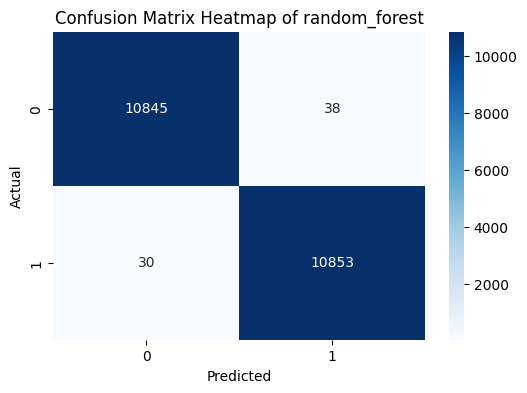

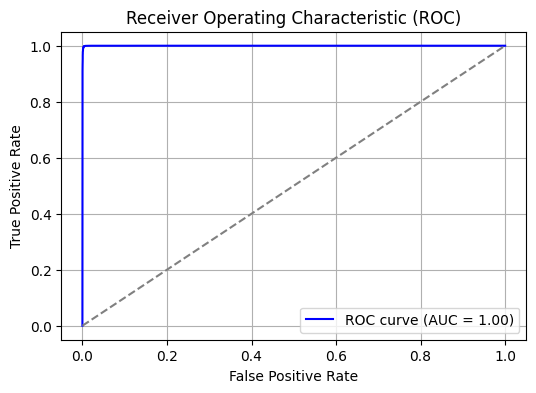

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10883
           1       1.00      1.00      1.00     10883

    accuracy                           1.00     21766
   macro avg       1.00      1.00      1.00     21766
weighted avg       1.00      1.00      1.00     21766



In [66]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]
model = 'random_forest'
record_PCA[model] = accuracy_score(y_test, y_pred)

print_metrics(model, y_test, y_pred, y_proba)
plot_confusion_matrix_heatmap(model, y_test, y_pred)
plot_roc_curve(y_test, y_proba)
print(classification_report(y_test, y_pred))

### comparision

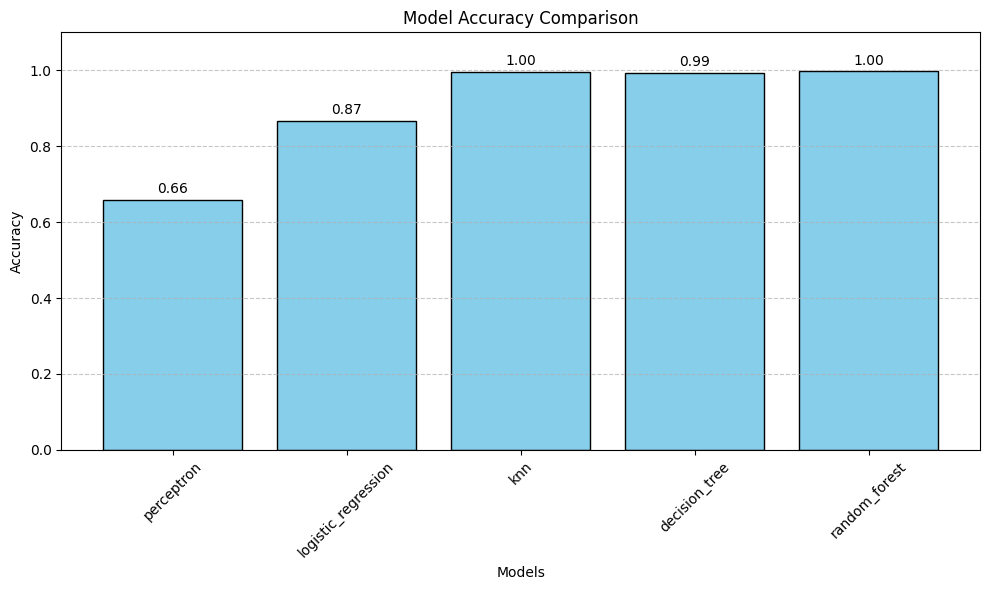

In [67]:
plot_accuracy_comparison(record_PCA)

#ANN before smote

### ANN

In [68]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_auc_score



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


681/681 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Metrics for ann :
---------------------------------
Accuracy       : 0.9971
Precision      : 0.9947
Recall         : 0.9995
F1 Score       : 0.9971


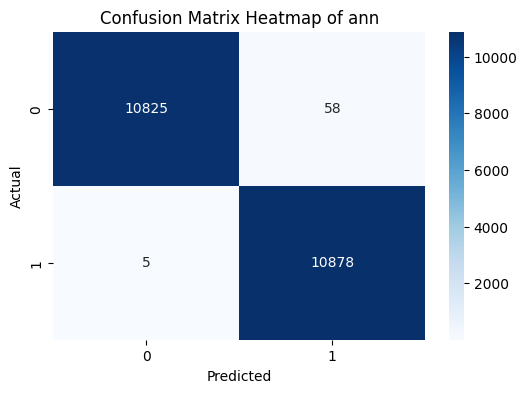

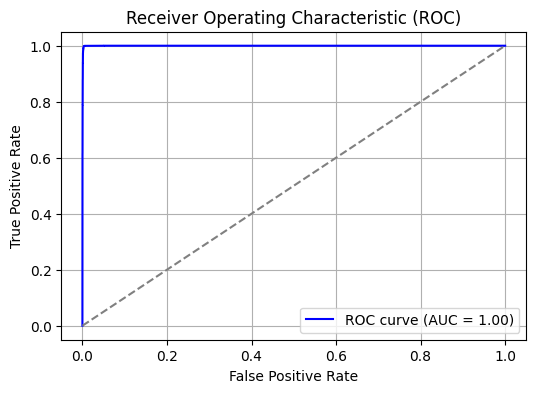

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     10883
           1       0.99      1.00      1.00     10883

    accuracy                           1.00     21766
   macro avg       1.00      1.00      1.00     21766
weighted avg       1.00      1.00      1.00     21766



In [69]:
record_ann={}
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ann = Sequential()
ann.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
ann.add(Dropout(0.3))
ann.add(Dense(32, activation='relu'))
ann.add(Dense(1, activation='sigmoid'))

ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = ann.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

y_pred_prob = ann.predict(X_test_scaled).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

model = 'ann'
record_ann[model] = accuracy_score(y_test, y_pred)

print_metrics(model, y_test, y_pred, y_pred_prob)
plot_confusion_matrix_heatmap(model, y_test, y_pred)
plot_roc_curve(y_test, y_pred_prob)
print(classification_report(y_test, y_pred))


### ANN with attention

In [70]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Multiply, Layer

In [71]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

class AttentionLayer(Layer):
    def __init__(self):
        super(AttentionLayer, self).__init__()

    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1), initializer='normal', trainable=True)
        self.b = self.add_weight(shape=(1,), initializer='zeros', trainable=True)

    def call(self, inputs):
        e = tf.nn.tanh(tf.matmul(inputs, self.W) + self.b)
        alpha = tf.nn.softmax(e, axis=1)
        return inputs * alpha

In [72]:
# input_layer = Input(shape=(X_train_scaled.shape[1],))
# attention = AttentionLayer()(input_layer)
# dense1 = Dense(64, activation='relu')(attention)
# drop1 = Dropout(0.3)(dense1)
# dense2 = Dense(32, activation='relu')(drop1)
# output = Dense(1, activation='sigmoid')(dense2)

# model_attn = Model(inputs=input_layer, outputs=output)
# model_attn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# model_attn.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# y_pred_prob = model_attn.predict(X_test_scaled).ravel()
# y_pred = (y_pred_prob > 0.5).astype(int)

# model = 'ann_attention_before_smote'
# record_atten_ann = {}
# record_atten_ann[model] = accuracy_score(y_test, y_pred)

# print_metrics(model, y_test, y_pred, y_pred_prob)
# plot_confusion_matrix_heatmap(model, y_test, y_pred)
# plot_roc_curve(y_test, y_pred_prob)
# print(classification_report(y_test, y_pred))


### comparision between ann and ann with attention before smote

In [73]:
# from sklearn.metrics import precision_score, recall_score, f1_score
# import pandas as pd

# models = []
# accuracys = []
# precisions = []
# recalls = []
# f1_scores = []

# model = 'ANN'
# models.append(model)

# y_pred_prob_ann = ann.predict(X_test_scaled).ravel()
# y_pred_ann = (y_pred_prob_ann > 0.5).astype(int)

# accuracys.append(accuracy_score(y_test, y_pred_ann))
# precisions.append(precision_score(y_test, y_pred_ann))
# recalls.append(recall_score(y_test, y_pred_ann))
# f1_scores.append(f1_score(y_test, y_pred_ann))

# model = 'ANN with Attention'
# models.append(model)

# y_pred_prob_attn = model_attn.predict(X_test_scaled).ravel()
# y_pred_attn = (y_pred_prob_attn > 0.5).astype(int)

# accuracys.append(accuracy_score(y_test, y_pred_attn))
# precisions.append(precision_score(y_test, y_pred_attn))
# recalls.append(recall_score(y_test, y_pred_attn))
# f1_scores.append(f1_score(y_test, y_pred_attn))

# metrics = {
#     "Model": models,
#     "Accuracy": accuracys,
#     "Precision": precisions,
#     "Recall": recalls,
#     "F1-Score": f1_scores
# }

# df_metrics = pd.DataFrame(metrics)
# print(df_metrics)


In [74]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd

# sns.set(style="whitegrid")
# df_melted = pd.melt(df_metrics, id_vars='Model', var_name='Metric', value_name='Score')
# plt.figure(figsize=(10, 6))
# ax = sns.barplot(x='Metric', y='Score', hue='Model', data=df_melted)
# for container in ax.containers:
#     ax.bar_label(container, fmt='%.4f', label_type='edge', fontsize=9, padding=3)

# plt.title('Comparison of ANN vs ANN with Attention (Before SMOTE)', fontsize=14)
# plt.ylim(0, 1.05)
# plt.ylabel('Score')
# plt.xlabel('Metric')
# plt.legend(title='Model')
# plt.tight_layout()
# plt.show()


# ANN AFTER SMOTE

In [75]:
from imblearn.over_sampling import SMOTE

In [76]:
# record_after_smote={}
# smote = SMOTE(random_state=42)
# X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# scaler = StandardScaler()
# X_train_resampled_scaled = scaler.fit_transform(X_train_resampled)
# X_test_scaled = scaler.transform(X_test)

# ann_smote = Sequential()
# ann_smote.add(Dense(64, activation='relu', input_shape=(X_train_resampled_scaled.shape[1],)))
# ann_smote.add(Dropout(0.3))
# ann_smote.add(Dense(32, activation='relu'))
# ann_smote.add(Dense(1, activation='sigmoid'))

# ann_smote.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ann_smote.fit(X_train_resampled_scaled, y_train_resampled, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# y_pred_prob = ann_smote.predict(X_test_scaled).ravel()
# y_pred = (y_pred_prob > 0.5).astype(int)

# model = 'ann_after_smote'
# record_after_smote[model] = accuracy_score(y_test, y_pred)

# print_metrics(model, y_test, y_pred, y_pred_prob)
# plot_confusion_matrix_heatmap(model, y_test, y_pred)
# plot_roc_curve(y_test, y_pred_prob)
# print(classification_report(y_test, y_pred))


### ANN WITH ATTENTION AFTER SMOTE

In [77]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_resampled_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

681/681 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Metrics for ann_attention_after_smote :
---------------------------------
Accuracy       : 0.9974
Precision      : 0.9957
Recall         : 0.9992
F1 Score       : 0.9974


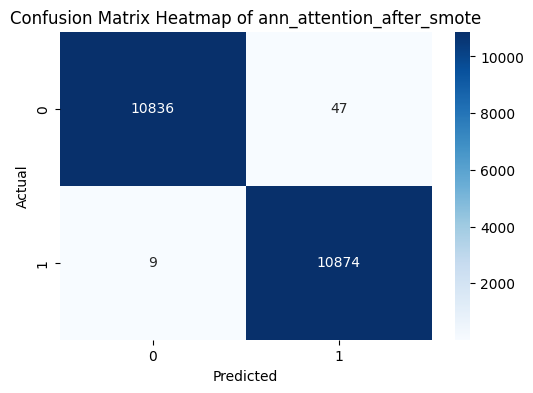

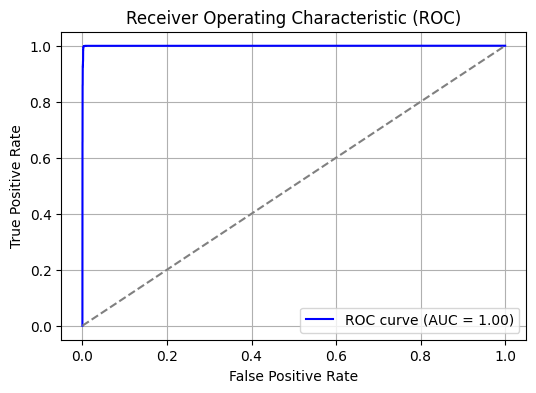

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10883
           1       1.00      1.00      1.00     10883

    accuracy                           1.00     21766
   macro avg       1.00      1.00      1.00     21766
weighted avg       1.00      1.00      1.00     21766



In [78]:
input_layer = Input(shape=(X_train_resampled_scaled.shape[1],))
attention = AttentionLayer()(input_layer)
dense1 = Dense(64, activation='relu')(attention)
drop1 = Dropout(0.3)(dense1)
dense2 = Dense(32, activation='relu')(drop1)
output = Dense(1, activation='sigmoid')(dense2)

model_attn_smote = Model(inputs=input_layer, outputs=output)
model_attn_smote.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model_attn_smote.fit(X_train_resampled_scaled, y_train_resampled, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

y_pred_prob = model_attn_smote.predict(X_test_scaled).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

model = 'ann_attention_after_smote'
record[model] = accuracy_score(y_test, y_pred)

print_metrics(model, y_test, y_pred, y_pred_prob)
plot_confusion_matrix_heatmap(model, y_test, y_pred)
plot_roc_curve(y_test, y_pred_prob)
print(classification_report(y_test, y_pred))


### COMPARISION OF ALL METRICS BETWEEN ANN AND ANN WITH ATTENTION AFTER SMOTE

In [79]:
# from sklearn.metrics import precision_score, recall_score, f1_score
# import pandas as pd

# models = []
# accuracys = []
# precisions = []
# recalls = []
# f1_scores = []

# model = 'ann_after_smote'
# y_pred_prob = ann_smote.predict(X_test_scaled).ravel()
# y_pred = (y_pred_prob > 0.5).astype(int)

# models.append(model)
# accuracys.append(accuracy_score(y_test, y_pred))
# precisions.append(precision_score(y_test, y_pred))
# recalls.append(recall_score(y_test, y_pred))
# f1_scores.append(f1_score(y_test, y_pred))
# model = 'ann_attention_after_smote'
# y_pred_prob = model_attn_smote.predict(X_test_scaled).ravel()
# y_pred = (y_pred_prob > 0.5).astype(int)

# models.append(model)
# accuracys.append(accuracy_score(y_test, y_pred))
# precisions.append(precision_score(y_test, y_pred))
# recalls.append(recall_score(y_test, y_pred))
# f1_scores.append(f1_score(y_test, y_pred))

# metrices = {
#     "Model": models,
#     "Accuracy": accuracys,
#     "Precision": precisions,
#     "Recall": recalls,
#     "F1-Score": f1_scores
# }

# df_metrics_after_smote = pd.DataFrame(metrices)
# print(df_metrics_after_smote)


BAR GRAPH

In [80]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd

# sns.set(style="whitegrid")

# df_melted = pd.melt(df_metrics_after_smote, id_vars='Model', var_name='Metric', value_name='Score')

# plt.figure(figsize=(10, 6))
# ax = sns.barplot(x='Metric', y='Score', hue='Model', data=df_melted)

# for container in ax.containers:
#     ax.bar_label(container, fmt='%.4f', label_type='edge', fontsize=9, padding=3)

# plt.title('Comparison of ANN vs ANN with Attention (After SMOTE)', fontsize=14)
# plt.ylim(0, 1.05)
# plt.ylabel('Score')
# plt.xlabel('Metric')
# plt.legend(title='Model')
# plt.tight_layout()
# plt.show()


# ANN WITH PCA

In [89]:
from sklearn.decomposition import PCA

In [90]:
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# pca = PCA(n_components=0.95)
# X_train_pca = pca.fit_transform(X_train_scaled)
# X_test_pca = pca.transform(X_test_scaled)

# ann_pca = Sequential()
# ann_pca.add(Dense(64, activation='relu', input_shape=(X_train_pca.shape[1],)))
# ann_pca.add(Dropout(0.3))
# ann_pca.add(Dense(32, activation='relu'))
# ann_pca.add(Dense(1, activation='sigmoid'))

# ann_pca.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ann_pca.fit(X_train_pca, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# y_pred_prob = ann_pca.predict(X_test_pca).ravel()
# y_pred = (y_pred_prob > 0.5).astype(int)

# model = 'ann_with_pca'
# record[model] = accuracy_score(y_test, y_pred)

# print_metrics(model, y_test, y_pred, y_pred_prob)
# plot_confusion_matrix_heatmap(model, y_test, y_pred)
# plot_roc_curve(y_test, y_pred_prob)
# print(classification_report(y_test, y_pred))


### ANN WITH ATTENTION WITH PCA

In [91]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [92]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

681/681 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Metrics for ann_attention_with_pca :
---------------------------------
Accuracy       : 0.9977
Precision      : 0.9965
Recall         : 0.9990
F1 Score       : 0.9978


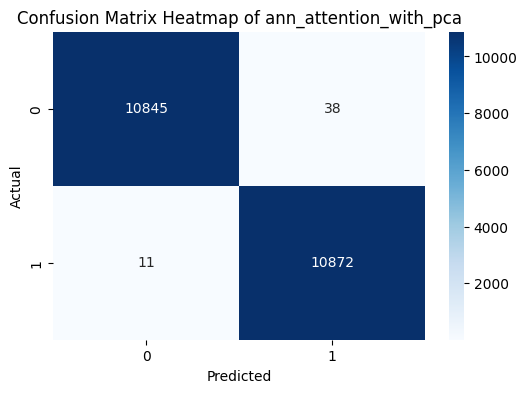

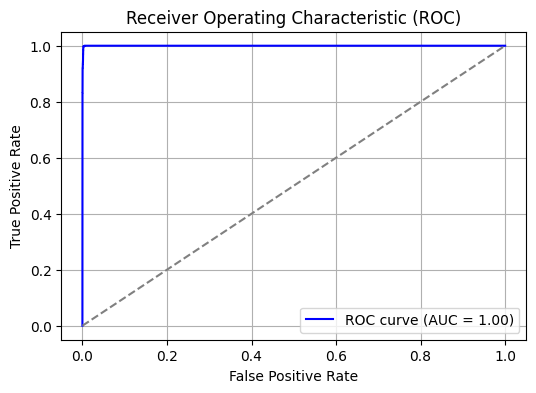

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10883
           1       1.00      1.00      1.00     10883

    accuracy                           1.00     21766
   macro avg       1.00      1.00      1.00     21766
weighted avg       1.00      1.00      1.00     21766



In [93]:
from tensorflow.keras.layers import Input

input_layer = Input(shape=(X_train_pca.shape[1],))
attention = AttentionLayer()(input_layer)
dense1 = Dense(64, activation='relu')(attention)
drop1 = Dropout(0.3)(dense1)
dense2 = Dense(32, activation='relu')(drop1)
output = Dense(1, activation='sigmoid')(dense2)

model_attn_pca = Model(inputs=input_layer, outputs=output)
model_attn_pca.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model_attn_pca.fit(X_train_pca, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

y_pred_prob = model_attn_pca.predict(X_test_pca).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

model = 'ann_attention_with_pca'
record[model] = accuracy_score(y_test, y_pred)

print_metrics(model, y_test, y_pred, y_pred_prob)
plot_confusion_matrix_heatmap(model, y_test, y_pred)
plot_roc_curve(y_test, y_pred_prob)
print(classification_report(y_test, y_pred))

### COMPARISION OF ALL METRICS BETWEEN ANN AND ANN WITH ATTENTION WITH PCA

In [94]:
# from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
# import pandas as pd

# models = []
# accuracys = []
# precisions = []
# recalls = []
# f1_scores = []

# model = 'ann_with_pca'
# y_pred_prob = ann_pca.predict(X_test_pca).ravel()
# y_pred = (y_pred_prob > 0.5).astype(int)

# models.append(model)
# accuracys.append(accuracy_score(y_test, y_pred))
# precisions.append(precision_score(y_test, y_pred))
# recalls.append(recall_score(y_test, y_pred))
# f1_scores.append(f1_score(y_test, y_pred))

# model = 'ann_attention_with_pca'
# y_pred_prob = model_attn_pca.predict(X_test_pca).ravel()
# y_pred = (y_pred_prob > 0.5).astype(int)

# models.append(model)
# accuracys.append(accuracy_score(y_test, y_pred))
# precisions.append(precision_score(y_test, y_pred))
# recalls.append(recall_score(y_test, y_pred))
# f1_scores.append(f1_score(y_test, y_pred))

# metrices = {
#     "Model": models,
#     "Accuracy": accuracys,
#     "Precision": precisions,
#     "Recall": recalls,
#     "F1-Score": f1_scores
# }

# df_metrics_with_pca = pd.DataFrame(metrices)
# print(df_metrics_with_pca)


BAR GRAPH

In [95]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd

# sns.set(style="whitegrid")

# df_melted = pd.melt(df_metrics_with_pca, id_vars='Model', var_name='Metric', value_name='Score')

# plt.figure(figsize=(10, 6))
# ax = sns.barplot(x='Metric', y='Score', hue='Model', data=df_melted)

# for container in ax.containers:
#     ax.bar_label(container, fmt='%.4f', label_type='edge', fontsize=9, padding=3)

# plt.title('Comparison of ANN vs ANN with Attention (With PCA)', fontsize=14)
# plt.ylim(0, 1.05)
# plt.ylabel('Score')
# plt.xlabel('Metric')
# plt.legend(title='Model')
# plt.tight_layout()
# plt.show()


ANN with Attention + PCA + SMOTE -- best model

681/681 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
681/681 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Overall Comparison of ANN Models:
                            Model  Accuracy  Precision    Recall  F1-Score
0  ANN with Attention After SMOTE  0.997427   0.995696  0.999173  0.997432
1     ANN with Attention with PCA  0.997749   0.996517  0.998989  0.997752


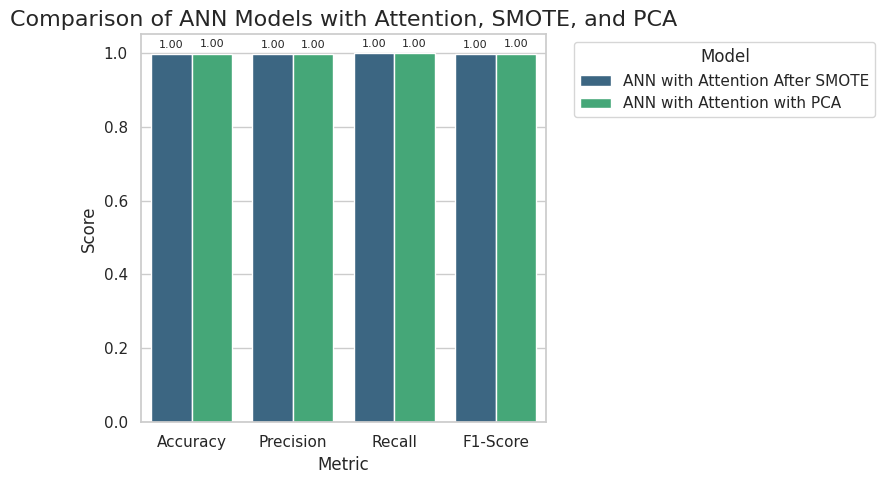

In [100]:
# prompt: can you please compare the comaparision metrics of ann with attention before , after smote and with pca

import pandas as pd
import matplotlib.pyplot as plt
# Overall Comparison of ANN Models
models = []
accuracys = []
precisions = []
recalls = []
f1_scores = []

# ANN with Attention After SMOTE
model = 'ANN with Attention After SMOTE'
y_pred_prob = model_attn_smote.predict(X_test_scaled).ravel() # X_test_scaled here is from the after SMOTE section
y_pred = (y_pred_prob > 0.5).astype(int)

models.append(model)
accuracys.append(accuracy_score(y_test, y_pred))
precisions.append(precision_score(y_test, y_pred))
recalls.append(recall_score(y_test, y_pred))
f1_scores.append(f1_score(y_test, y_pred))

# ANN with Attention with PCA
model = 'ANN with Attention with PCA'
y_pred_prob = model_attn_pca.predict(X_test_pca).ravel() # X_test_pca is from the PCA section
y_pred = (y_pred_prob > 0.5).astype(int)

models.append(model)
accuracys.append(accuracy_score(y_test, y_pred))
precisions.append(precision_score(y_test, y_pred))
recalls.append(recall_score(y_test, y_pred))
f1_scores.append(f1_score(y_test, y_pred))


metrics_summary = {
    "Model": models,
    "Accuracy": accuracys,
    "Precision": precisions,
    "Recall": recalls,
    "F1-Score": f1_scores
}

df_metrics_summary = pd.DataFrame(metrics_summary)
print("\nOverall Comparison of ANN Models:")
print(df_metrics_summary)

# BAR GRAPH for overall comparison
sns.set(style="whitegrid")

df_melted_summary = pd.melt(df_metrics_summary, id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 5))
ax = sns.barplot(x='Metric', y='Score', hue='Model', data=df_melted_summary, palette='viridis')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2 f', label_type='edge', fontsize=8, padding=3)

plt.title('Comparison of ANN Models with Attention, SMOTE, and PCA', fontsize=16)
plt.ylim(0, 1.05)
plt.ylabel('Score')
plt.xlabel('Metric')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for the legend
plt.show()


In [ ]:
# prompt: please give the classification report of then tabular format

# Print classification report in tabular format
print(classification_report(y_test, y_pred, output_dict=True))


In [ ]:
please give the classification report of then tabular format of ann  with attention of before smote,after smote, wuth pca